# 2.2.2 Attention機構の実装

- Attention重み(注意度): 特定のクエリに対する各キーの注意度
- Attention出力: Attention重みとバリューを掛け合わせてその結果を合計したもの

In [28]:
import numpy as np

# softmax関数の実装
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=-1, keepdims=True)

# Attention機構の実装
def attention(Q, K, V):
    attention_weights = softmax(np.matmul(Q, K.T)) # Attention重み(matmulは行列積)
    output = np.matmul(attention_weights, V) # Attention重みとVの行列積(Attention重みとバリューベクトルを掛けて足し合わせたもの)
    return output, attention_weights # Attention出力とAttention重みを返す

In [29]:
import math

# サンプルベクトル(キー/バリューベクトル)の作成
n = 10
vectors = []
# 360°をn等分した角度
theta = 2 * math.pi / n
for i in range(n):
    x = math.cos(theta * i)
    y = math.sin(theta * i)
    vectors.append([x, y])
vectors = np.array(vectors) # キー/バリューベクトルに対応
print("vectorsの形状:", vectors.shape) # (n, 2)の形状を持つことを確認(2次元ベクトルを10個)

# サンプルクエリベクトルの作成(これに対するAttentionを計算する)
query = np.array([1 / math.sqrt(2), 1 / math.sqrt(2)])

# Attentionの計算
output, attention_weights = attention(query, vectors, vectors)

import pandas as pd
index = np.arange(n)
attention_df = pd.DataFrame(data=attention_weights, index=index, columns=["クエリに対するAttention重み"])
print(attention_df)

print("Attention重みの形状:", attention_weights.shape) # n次元ベクトルになる
print("Attention重みの和:", attention_weights.sum())

print("Attention出力:", output) # Attention重みとVの行列積(Attention重みとバリューベクトルを掛けて足し合わせたもの)
print("Attention出力の形状:", output.shape) # 2次元(valueの次元)ベクトルになる

vectorsの形状: (10, 2)
   クエリに対するAttention重み
0            0.160190
1            0.212076
2            0.192532
3            0.124368
4            0.067547
5            0.038945
6            0.029417
7            0.032403
8            0.050162
9            0.092360
Attention重みの形状: (10,)
Attention重みの和: 1.0000000000000002
Attention出力: [0.31564538 0.31564537]
Attention出力の形状: (2,)


(参考) matmulについて

In [30]:
import numpy as np
a = np.array([1, 2, 3])
b = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
c = np.matmul(a, b) # 行列積
print(c)

[30 36 42]


In [31]:
import matplotlib.pyplot as plt
import japanize_matplotlib


def plot_vectors(vectors, texts, ax, arrow_args={}, text_args={}):
    for i, (x, y) in enumerate(vectors):
        ax.annotate("", xy=[x, y], xytext=[0, 0], arrowprops=arrow_args)
        ax.text(x * 1.1, y * 1.1, texts[i], **text_args)


def plot_attention_hist(attention_weights, ax):
    ax.bar(range(len(attention_weights)), attention_weights)
    ax.set_xticks(range(len(attention_weights)))
    ax.set_xticklabels([f"$v_{i+1}$" for i in range(len(attention_weights))])
    ax.set_ylabel("注意度")

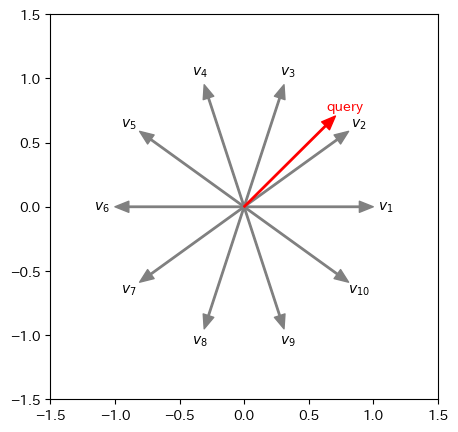

In [32]:
# vectors と query をプロット
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
texts = [f"$v_{{{i+1}}}$" for i in range(n)]
arrow_args1 = dict(
    width=1, headwidth=8, headlength=10, facecolor="gray", edgecolor="gray"
)
text_args1 = dict(ha="center", va="center")
plot_vectors(
    vectors,
    texts,
    ax,
    arrow_args=arrow_args1,
    text_args=text_args1,
)
arrow_args2 = dict(
    width=1, headwidth=8, headlength=10, facecolor="red", edgecolor="red"
)
text_args2 = dict(ha="center", va="center", color="red")
plot_vectors([query], ["query"], ax, arrow_args=arrow_args2, text_args=text_args2)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

fig.savefig("vectors_and_query.png", dpi=144)
plt.show()

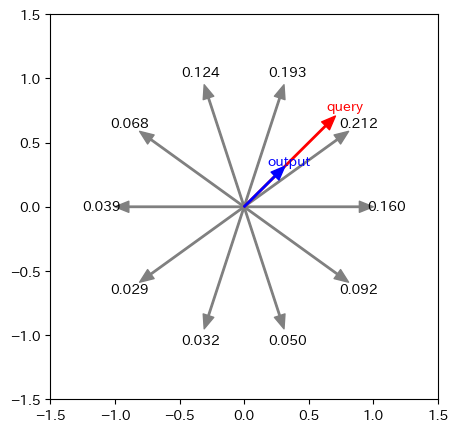

In [33]:
# attention weights をプロット
def plot_attention_weights(vectors, query, output, attention_weights, ax):
    texts = [f"{a:.3f}" for a in attention_weights]

    arrow_args1 = dict(
        width=1, headwidth=8, headlength=10, facecolor="gray", edgecolor="gray"
    )
    text_args1 = dict(ha="center", va="center")
    plot_vectors(
        vectors,
        texts,
        ax,
        arrow_args=arrow_args1,
        text_args=text_args1,
    )
    arrow_args2 = dict(
        width=1, headwidth=8, headlength=10, facecolor="red", edgecolor="red"
    )
    text_args2 = dict(ha="center", va="center", color="red")
    plot_vectors([query], ["query"], ax, arrow_args=arrow_args2, text_args=text_args2)

    arrow_args3 = dict(
        width=1, headwidth=8, headlength=10, facecolor="blue", edgecolor="blue"
    )
    text_args3 = dict(ha="center", va="center", color="blue")
    plot_vectors([output], ["output"], ax, arrow_args=arrow_args3, text_args=text_args3)


fig, ax = plt.subplots(figsize=(5, 5))
plot_attention_weights(vectors, query, output, attention_weights, ax)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

fig.savefig("attention_weights.png", dpi=144)
plt.show()

In [34]:
# 1つだけ長いベクトルがある場合の実験

vectors2 = vectors.copy()
vectors2[3] = vectors2[3] * 5

_, attention_weights2 = attention(query, vectors2, vectors2)

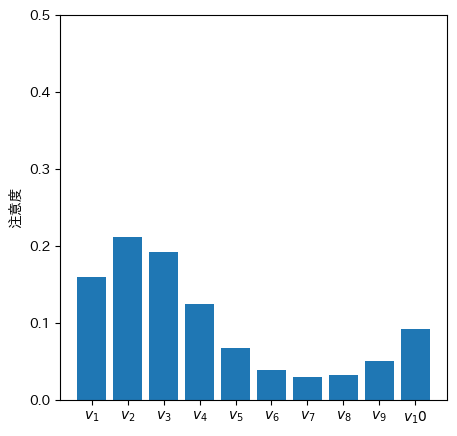

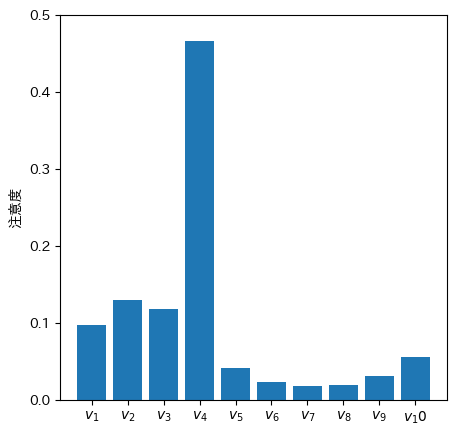

In [35]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_attention_hist(attention_weights, ax)
ax.set_ylim(0, 0.5)
fig.savefig("attention_weights_hist1.png", dpi=144)
plt.show()
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_ylim(0, 0.5)
plot_attention_hist(attention_weights2, ax)
fig.savefig("attention_weights_hist2.png", dpi=144)
plt.show()

In [36]:
queries = np.array([[1 / math.sqrt(2), 1 / math.sqrt(2)], [1, 0], [0, 1]])

output, attention_weights = attention(queries, vectors, vectors)
print("Attention出力の形:", output.shape)
print("Attention重みの形:", attention_weights.shape)
print("Attention重みの行ごとの和:", attention_weights.sum(axis=1))

Attention出力の形: (3, 2)
Attention重みの形: (3, 10)
Attention重みの行ごとの和: [1. 1. 1.]


# 2.2.3 スケール化内積Attentionの実装

In [37]:
import numpy as np

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=-1, keepdims=True)

def attention(Q, K, V): # スケール化なし
    attention_weights = softmax(np.matmul(Q, K.T))
    return np.matmul(attention_weights, V), attention_weights

## Softmax関数の検証
softmax関数に入力される値が大きくなる(x1)と、出力が0に近い値になる。

In [38]:
x1 = np.random.randn(100) * 10
x2 = np.random.randn(100)

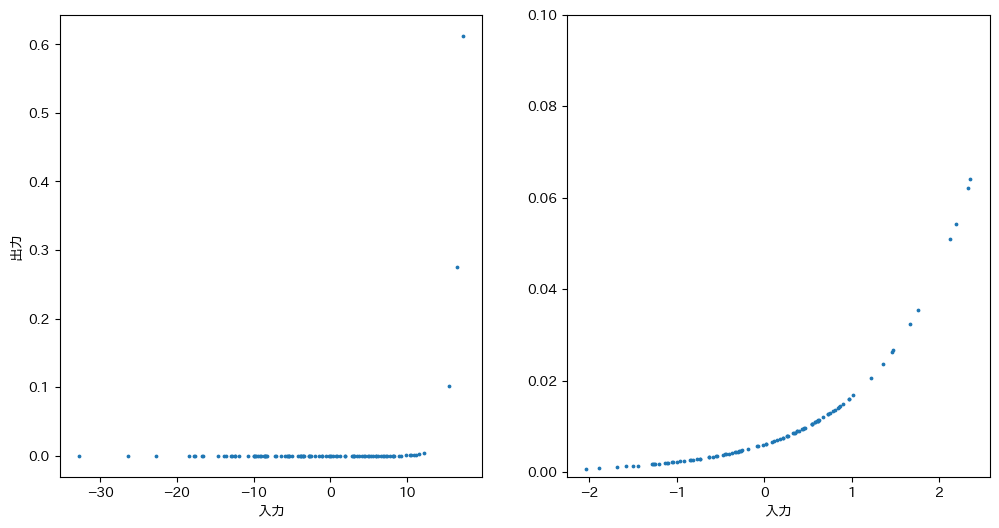

In [39]:
import matplotlib.pyplot as plt
import japanize_matplotlib

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(x1, softmax(x1), s=3)
ax2.scatter(x2, softmax(x2), s=3)
# ax1.set_ylim(-0.001, 0.1)
ax2.set_ylim(-0.001, 0.1)
ax1.set_xlabel("入力")
ax2.set_xlabel("入力")
ax1.set_ylabel("出力")

fig.savefig("softmax_different_ranges.png", dpi=144)

## スケーリングあり/なしによるAttention重みの比較

スケール化しないと次元が大きくなった時にsoftmax関数の出力が0に近くなり要素間の違いが出辛くなる。

In [40]:
# 異なる次元(1次元と100次元)のクエリ/キーベクトルを用意
dim1 = 1
dim2 = 100
n_keys = 20

q1 = np.random.randn(dim1)
q2 = np.random.randn(dim2)
k1 = np.random.randn(n_keys, dim1)
k2 = np.random.randn(n_keys, dim2)

In [41]:
dot1 = np.matmul(k1, q1)
s1_1 = softmax(dot1)
s1_2 = softmax(dot1 / np.sqrt(dim1))  # スケール化

dot2 = np.matmul(k2, q2)
s2_1 = softmax(dot2)
s2_2 = softmax(dot2 / np.sqrt(dim2)) # スケール化

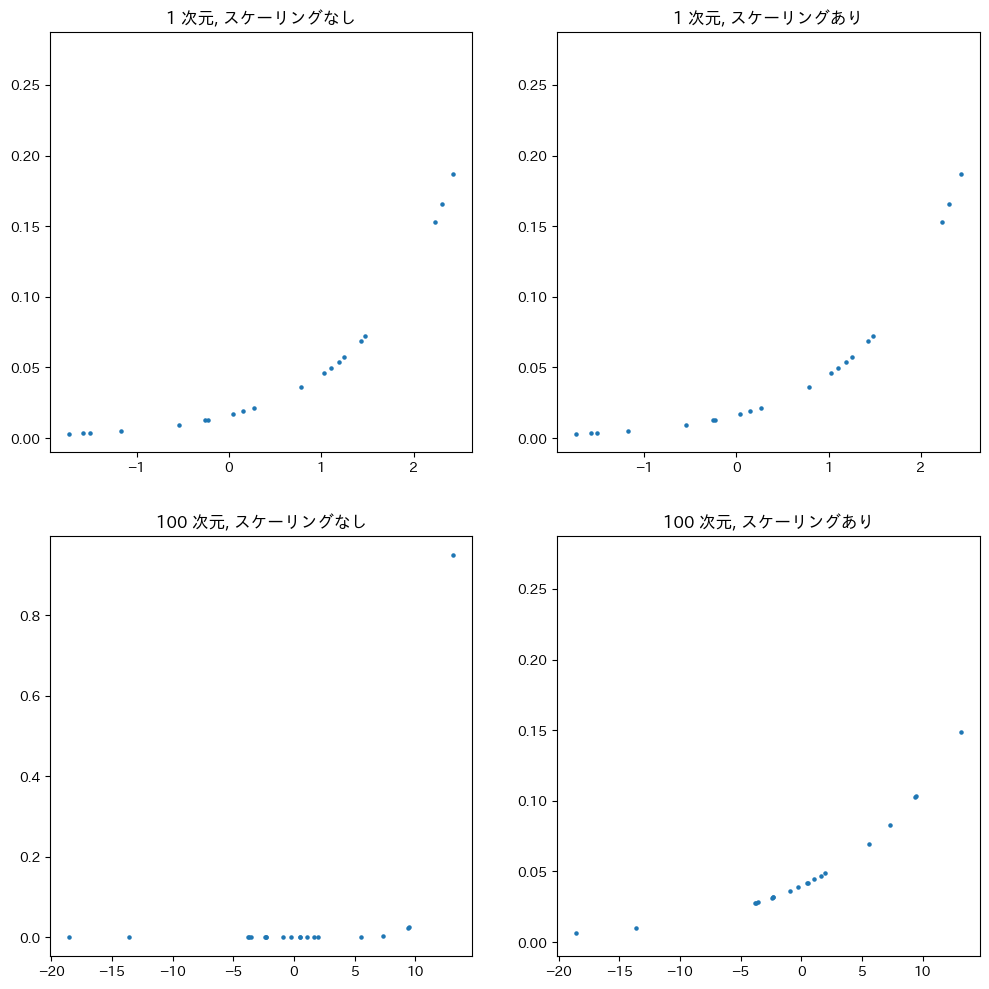

In [42]:
fig, ax = plt.subplots(2, 2, figsize=(12, 12))

max_1_2 = max(np.max(s1_2), np.max(s2_2))
ax[0, 0].scatter(dot1, s1_1, s=5)
ax[0, 0].set_title(f"{dim1} 次元, スケーリングなし")
ax[0, 0].set_ylim(-0.01, max_1_2 + 0.1)
ax[0, 1].scatter(dot1, s1_2, s=5)
ax[0, 1].set_title(f"{dim1} 次元, スケーリングあり")
ax[0, 1].set_ylim(-0.01, max_1_2 + 0.1)
ax[1, 0].scatter(dot2, s2_1, s=5)
ax[1, 0].set_title(f"{dim2} 次元, スケーリングなし")
ax[1, 1].scatter(dot2, s2_2, s=5)
ax[1, 1].set_title(f"{dim2} 次元, スケーリングあり")
ax[1, 1].set_ylim(-0.01, max_1_2 + 0.1)

fig.savefig("softmax_scaling.png", dpi=144)

## スケール化内積Attentionの実装

Q,Kの次元(dim)が大きくなると内積の値が大きくなるため`sqrt(dim)`で割ってスケール化する。

In [43]:
def scaled_attention(Q, K, V):
    dim = Q.shape[-1]
    attention_weights = softmax(np.matmul(Q, K.T) / np.sqrt(dim))
    return np.matmul(attention_weights, V), attention_weights

In [44]:
import math
import numpy as np

# サンプルベクトル(キー/バリューベクトル)の作成
n = 10
vectors = []
# 360°をn等分した角度
theta = 2 * math.pi / n
for i in range(n):
    x = math.cos(theta * i)
    y = math.sin(theta * i)
    vectors.append([x, y])
vectors = np.array(vectors) # キー/バリューベクトルに対応

# サンプルクエリベクトルの作成(これに対するAttentionを計算する)
query = np.array([1 / math.sqrt(2), 1 / math.sqrt(2)])
print("クエリベクトル:", query)
print("クエリベクトルの形状:", query.shape)

クエリベクトル: [0.70710678 0.70710678]
クエリベクトルの形状: (2,)


In [45]:
output, attention_weights = scaled_attention(query, vectors, vectors)

import pandas as pd
index = np.arange(n)

print("Attention出力:", output) # Attention重みとVの内積(Attention重みとバリューベクトルを掛けて足し合わせたもの)
attention_df = pd.DataFrame(data=attention_weights, index=index, columns=["クエリに対するAttention重み"])
print(attention_df)

print("Attention重みの形:", attention_weights.shape)
print("Attention重みの和:", attention_weights.sum())


Attention出力: [0.23557408 0.23557408]
   クエリに対するAttention重み
0            0.146039
1            0.178087
2            0.166319
3            0.122106
4            0.079301
5            0.053725
6            0.044056
7            0.047174
8            0.064255
9            0.098938
Attention重みの形: (10,)
Attention重みの和: 0.9999999999999999


# マルチヘッドアッテンション

# サンプル配列の用意
バッチサイズ=2で、クエリ、キー、バリューの配列を作成。

In [46]:
# サンプル配列の用意
import torch

batch_size = 2
d_model = 16 # q, k, v の次元(ベクトルの要素数)
n_heads = 4 # マルチヘッドアテンションのヘッド数

# 変換後の次元
d_k = d_model // n_heads # 一般的に変換後の次元はd_modelをヘッド数で割ったものとする
d_v = d_k

query_len, key_len, value_len = 3, 4, 4

query = torch.randn(batch_size, query_len, d_model)
key = torch.randn(batch_size, key_len, d_model)
value = torch.randn(batch_size, value_len, d_model)

print("d_model:", d_model)
print("n_heads:", n_heads)
print("d_k:", d_k)
print("d_v:", d_v)

print("クエリの形:", query.shape)
print("キーの形:", key.shape)
print("バリューの形:", value.shape)

d_model: 16
n_heads: 4
d_k: 4
d_v: 4
クエリの形: torch.Size([2, 3, 16])
キーの形: torch.Size([2, 4, 16])
バリューの形: torch.Size([2, 4, 16])


# 2.2.8 PyTorchを用いた内積Attentionの実装

(注意)これはこの後は使わない

`torch.bmm`は行列積をバッチ用に拡張したもの(バッチの次元を考慮して行列積を計算)

In [47]:
import torch
from torch import Tensor, nn

class DotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    # 内積Attentionの計算
    def forward(self, query: Tensor, key: Tensor, value: Tensor) -> Tensor:
        # バッチ毎にqueryとkeyの内積を計算
        #   transpose(1, 2)は、keyの最後の2次元を入れ替えることで、queryとkeyの内積が計算できるようにするためのもの
        #   K.Tと同じ
        score = torch.bmm(query, key.transpose(1, 2)) 
        weight = torch.softmax(score, dim=-1)  # queryとkeyの内積をsoftmaxで正規化して重みを計算
        output = torch.bmm(weight, value)  # バッチ毎にvalueの重み付き和を計算
        return output

In [48]:
# テスト実行
dot_product_attention = DotProductAttention()
output = dot_product_attention(query, key, value)
print("Attentionの出力の形:", output.shape)

Attentionの出力の形: torch.Size([2, 3, 16])


# 2.2.9 PyTorchを用いたスケール化内積Attentionの実装

In [49]:
import math
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    # スケール化内積Attentionの計算
    def forward(self, query: Tensor, key: Tensor, value: Tensor) -> Tensor:
        d_k = query.size(-1) # queryの次元数(=keyの次元数(ベクトルの要素数))でスケーリング
        # バッチ毎にqueryとkeyの内積を計算
        # 内積を次元数の平方根で割ることでスケーリング
        #   transpose(1, 2)は、keyの最後の2次元を入れ替えることで、queryとkeyの内積が計算できるようにするためのもの
        #   K.Tと同じ
        score = torch.bmm(query, key.transpose(1, 2)) / math.sqrt(d_k) 
        attention_weights = torch.softmax(score, dim=-1)  # バッチ毎にAttention重みを計算
        output = torch.bmm(attention_weights, value)  # バッチ毎にAttention出力を計算
        
        return output

In [50]:
# テスト実行
scaled_dot_product_attention = ScaledDotProductAttention()
output = scaled_dot_product_attention(query, key, value)

print("Attention出力:", output) # Attention重みとVの内積(Attention重みとバリューベクトルを掛けて足し合わせたもの)
print("Attentionの出力の形状:", output.shape)

Attention出力: tensor([[[ 0.3056,  0.0580, -0.4428, -0.7143,  0.7512,  0.9026, -0.2339,
           0.9934, -0.3750, -0.1766,  0.6132, -0.2927, -0.0314,  0.2986,
          -0.1992, -0.7794],
         [ 0.1601,  0.0631, -0.5188, -1.0726,  0.8851,  1.1236, -0.5691,
           1.1706, -0.6428, -0.4958,  0.5561, -0.3961, -0.1704,  0.3759,
          -0.0299, -1.0908],
         [ 0.2831,  0.1244, -0.2292, -0.4629,  0.6045,  1.2434, -0.2442,
           0.6358,  0.1171,  0.1726,  0.5918, -0.0072, -0.0513,  0.4263,
          -0.5252, -0.3225]],

        [[ 0.7986,  0.0702,  0.0443, -0.3824,  0.3401,  0.9369,  0.0567,
          -0.0562, -0.3125,  0.9000,  0.5614, -0.5885,  1.5871, -0.7369,
          -0.4149,  0.0409],
         [ 0.6555, -0.3721, -0.2498, -0.2782, -0.2416,  1.1782,  0.4540,
           0.3009, -0.4825,  0.7308,  0.5150,  0.2644,  1.1958, -0.3109,
          -0.4333, -0.2384],
         [ 0.5216, -0.2390,  0.3292, -0.7025,  0.3229,  0.8143,  0.2639,
          -0.0133, -0.4998,  1.0205, 

# 2.2.10 マルチヘッドAttentionの実装

In [51]:
# スケール化内積Attentionのクラスを定義
import math
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    # スケール化内積Attentionの計算
    def forward(self, query: Tensor, key: Tensor, value: Tensor) -> Tensor:
        d_k = query.size(-1) # queryの次元数(=keyの次元数(ベクトルの要素数))でスケーリング
        # バッチ毎にqueryとkeyの内積を計算
        # 内積を次元数の平方根で割ることでスケーリング
        #   transpose(1, 2)は、keyの最後の2次元を入れ替えることで、queryとkeyの内積が計算できるようにするためのもの
        #   K.Tと同じ
        score = torch.bmm(query, key.transpose(1, 2)) / math.sqrt(d_k) 
        attention_weights = torch.softmax(score, dim=-1)  # バッチ毎にAttention重みを計算
        output = torch.bmm(attention_weights, value)  # バッチ毎にAttention出力を計算
        
        return output


# 1つのヘッドに対するAttentionの計算を行うクラス(O'を計算する部分)
class AttentionHead(nn.Module):
    def __init__(self, d_k: int, d_v: int, d_model: int):
        super().__init__()
        # クエリ, キー, バリューそれぞれに対する線形層を定義
        self.linear_q = nn.Linear(d_model, d_k)  # w_qの線形層(出力をd_k(d_model/h)次元に変換)
        self.linear_k = nn.Linear(d_model, d_k)  # w_kの線形層(出力をd_k(d_model/h)次元に変換)
        self.linear_v = nn.Linear(d_model, d_v)  # w_vの線形層(出力をd_v(d_model/h)次元に変換)

        self.attention = ScaledDotProductAttention()

    def forward(
        self, query: Tensor, key: Tensor, value: Tensor) -> Tensor:
        query = self.linear_q(query)  # Q*W_qの計算
        key = self.linear_k(key)  # K*W_kの計算
        value = self.linear_v(value) # V*W_vの計算

        output = self.attention(query, key, value)
        return output

# マルチヘッドアテンションのクラス(Oを計算する部分)
class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads: int, d_k: int, d_v: int, d_model: int):
        super().__init__()
        # 各ヘッドの計算(O'を計算する部分)をModuleListでまとめる
        # ヘッド数(n_heads)分のAttentionHeadを作成してModuleListに格納
        self.heads = nn.ModuleList( 
            [AttentionHead(d_k, d_v, d_model) for _ in range(n_heads)]
        )
        # 出力を変換する全結合層(O'を線形層に通してOを計算する部分)
        self.linear_o = nn.Linear(n_heads * d_v, d_model)

    def forward(
        self, query: Tensor, key: Tensor, value: Tensor) -> Tensor:
        # 各ヘッドに対応するAttentionHeadのforwardメソッドを呼び出して、ヘッドごとの出力(O')を計算
        # 各ヘッドから(2, 3, 4)の形状の出力が得られるので、これをリストに格納
        head_out = [head(query, key, value) for head in self.heads]

        print("各ヘッドの出力(head_out):", head_out)
        
        # ヘッドを結合
        head_out = torch.cat(head_out, dim=-1) # 出力を横方向に結合(-> O')

        print("各ヘッドの出力を結合(head_out):", head_out)
        print(head_out.shape)

        output = self.linear_o(head_out) # O'を線形層に通してOを計算
        return output

In [52]:
# テスト実行

# マルチヘッドアテンションのインスタンスを作成
multihead_attention = MultiHeadAttention(n_heads, d_k, d_v, d_model)
print(multihead_attention)

# マルチヘッドアテンションの計算
output2 = multihead_attention(query, key, value)

print("マルチヘッドアテンションの出力:", output2)
print("マルチヘッドアテンションの出力の形:", output2.shape)


MultiHeadAttention(
  (heads): ModuleList(
    (0-3): 4 x AttentionHead(
      (linear_q): Linear(in_features=16, out_features=4, bias=True)
      (linear_k): Linear(in_features=16, out_features=4, bias=True)
      (linear_v): Linear(in_features=16, out_features=4, bias=True)
      (attention): ScaledDotProductAttention()
    )
  )
  (linear_o): Linear(in_features=16, out_features=16, bias=True)
)
各ヘッドの出力(head_out): [tensor([[[-0.1155,  0.5505, -0.0736, -0.0126],
         [-0.1242,  0.5710, -0.0739,  0.0107],
         [-0.1255,  0.5403, -0.0259, -0.0578]],

        [[-0.3070,  0.3385,  0.1641, -0.2014],
         [-0.3902,  0.3852,  0.1460, -0.1810],
         [-0.3454,  0.4036,  0.1884, -0.2044]]], grad_fn=<BmmBackward0>), tensor([[[-0.3742, -0.1184, -0.0586,  0.1024],
         [-0.4379, -0.1584,  0.0076,  0.1903],
         [-0.5419, -0.1732, -0.0462,  0.1788]],

        [[-0.9560, -0.1401,  0.0338,  0.0515],
         [-0.8650, -0.0982,  0.1390,  0.0463],
         [-0.8609, -0.1137,  0.

# nn.MultiheadAttention
[nn.MultiheadAttention](https://docs.pytorch.org/docs/2.11/generated/torch.nn.MultiheadAttention.html)

`torch.nn`にはTransformerを構成する主要部品の多くが実装されている。

| Transformerの部品            | PyTorchで使う代表例                                 |
| ------------------------- | --------------------------------------------------- |
| Embedding                 | `torch.nn.Embedding`                                |
| Multi-Head Attention      | `torch.nn.MultiheadAttention`                       |
| Feed Forward Network      | `torch.nn.Linear`, `torch.nn.GELU`, `torch.nn.ReLU` |
| Layer Normalization       | `torch.nn.LayerNorm`                                |
| Dropout                   | `torch.nn.Dropout`                                  |
| Transformer Encoder Layer | `torch.nn.TransformerEncoderLayer`                  |
| Transformer Encoder       | `torch.nn.TransformerEncoder`                       |
| Transformer Decoder Layer | `torch.nn.TransformerDecoderLayer`                  |
| Transformer Decoder       | `torch.nn.TransformerDecoder`                       |
| Transformer全体             | `torch.nn.Transformer`                             |


In [53]:
# サンプル配列の用意
import torch

batch_size = 2
d_model = 16 # q, k, v の次元(ベクトルの要素数)
n_heads = 4 # マルチヘッドアテンションのヘッド数

# 変換後の次元
d_k = d_model // n_heads # 一般的に変換後の次元はd_modelをヘッド数で割ったものとする
d_v = d_k

query_len, key_len, value_len = 3, 4, 4

query = torch.randn(batch_size, query_len, d_model)
key = torch.randn(batch_size, key_len, d_model)
value = torch.randn(batch_size, value_len, d_model)

print("d_model:", d_model)
print("n_heads:", n_heads)
print("d_k:", d_k)
print("d_v:", d_v)

print("クエリの形:", query.shape)
print("キーの形:", key.shape)
print("バリューの形:", value.shape)

d_model: 16
n_heads: 4
d_k: 4
d_v: 4
クエリの形: torch.Size([2, 3, 16])
キーの形: torch.Size([2, 4, 16])
バリューの形: torch.Size([2, 4, 16])


In [54]:
from torch import nn

multihead_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
attn_output, attn_output_weights = multihead_attn(query, key, value)

print("attn_output_weights.shape:", attn_output_weights.shape)
print(attn_output_weights)

print("attn_output.shape:", attn_output.shape)
print(attn_output)


attn_output_weights.shape: torch.Size([2, 3, 4])
tensor([[[0.2187, 0.2804, 0.2846, 0.2164],
         [0.1736, 0.1761, 0.2914, 0.3589],
         [0.2877, 0.2480, 0.2231, 0.2413]],

        [[0.2495, 0.2096, 0.3023, 0.2386],
         [0.2841, 0.1952, 0.2608, 0.2599],
         [0.2371, 0.2529, 0.2469, 0.2631]]], grad_fn=<MeanBackward1>)
attn_output.shape: torch.Size([2, 3, 16])
tensor([[[ 0.1567,  0.1996, -0.1445,  0.0913,  0.2664,  0.0772,  0.2698,
          -0.0403, -0.0519,  0.1375,  0.1633, -0.0389,  0.2001, -0.3522,
          -0.3168,  0.4017],
         [ 0.1277,  0.3286,  0.0391,  0.0929,  0.2705,  0.1208,  0.2141,
           0.3142, -0.0594,  0.1671,  0.4177,  0.1110,  0.3107, -0.4521,
          -0.1790,  0.4788],
         [-0.0323,  0.1980, -0.1038, -0.1431,  0.2328,  0.2433,  0.4018,
           0.0007, -0.0479,  0.2703,  0.2803, -0.1093,  0.3053, -0.3177,
          -0.1564,  0.3155]],

        [[ 0.0108, -0.3680, -0.3263,  0.2297,  0.1201,  0.1397, -0.3923,
          -0.2947, -0.